In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sympy import false
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
%matplotlib inline


torch.manual_seed(12046)

In [5]:
# 准备数据
dataset = datasets.MNIST(root='./data', train=True, download=False, transform=transforms.ToTensor())
# 将数据划分成训练集、验证集、测试集
train_set, val_set = random_split(dataset, [50000, 10000])
test_set = datasets.MNIST(root='./data', train=False, download=False, transform=transforms.ToTensor())
len(train_set), len(val_set), len(test_set)

(50000, 10000, 10000)

In [6]:
# 构建数据读取器
train_loader = DataLoader(train_set, batch_size=500, shuffle=True)
val_loader = DataLoader(val_set, batch_size=500, shuffle=True)
test_loader = DataLoader(test_set, batch_size=500, shuffle=True)

In [7]:
# 获取一个批量的数据
x, y = next(iter(train_loader))
x.shape, y.shape, x.view(x.shape[0], -1).shape

(torch.Size([500, 1, 28, 28]), torch.Size([500]), torch.Size([500, 784]))

In [8]:
# 两种常见的实现方式
## 自由度更大的实现方式
class MLP(nn.Module):

    def __init__(self):
        super().__init__()
        self.hidden1 = nn.Linear(784, 30)
        self.hidden2 = nn.Linear(30, 20)
        self.out = nn.Linear(20, 10)

    def forward(self, x):
        '''
        多层感知器的向前传播
        参数
        ----
        x ：torch.FloatTensor，形状为(B, 784)，其中B表示批量数据的大小
        '''
        x = F.sigmoid(self.hidden1(x))  # (B, 30)
        x = F.sigmoid(self.hidden2(x))  # (B, 20)
        x = self.out(x)                 # (B, 10)
        return x

model = MLP()

## 更简洁的实现方式
model = nn.Sequential(
    nn.Linear(784, 30), nn.Sigmoid(),
    nn.Linear( 30, 20), nn.Sigmoid(),
    nn.Linear( 20, 10)
)

In [9]:
eval_iters = 10

def estimate_loss(model):
    re = {}
    # 将模型切换至评估模式
    model.eval()
    re['train'] = _loss(model, train_loader)
    re['val'] = _loss(model, val_loader)
    re['test'] = _loss(model, test_loader)
    # 将模型切换至训练模式
    model.train()
    return re

@torch.no_grad()
def _loss(model, data_loader):
    """
    计算模型在不同数据集下面的评估指标
    """
    loss = []
    accuracy = []
    data_iter = iter(data_loader)
    for k in range(eval_iters):
        inputs, labels = next(data_iter)
        B, C, H, W = inputs.shape
        # 将数据转换成模型输入要求的形状
        # 也可以用如下的命令来完成：inputs.view(-1, 784)
        logits = model(inputs.view(B, -1))
        # 计算模型损失
        loss.append(F.cross_entropy(logits, labels))
        # 计算预测的准确率
        _, predicted = torch.max(logits, 1)
        accuracy.append((predicted == labels).sum() / B)
    re = {
        'loss': torch.tensor(loss).mean().item(),
        'accuracy': torch.tensor(accuracy).mean().item()
    }
    return re

In [10]:
def train_mlp(model, optimizer, data_loader, epochs=10, penalty=[]):
    lossi = []
    for epoch in range(epochs):
        for i, data in enumerate(data_loader, 0):
            inputs, labels = data
            optimizer.zero_grad()
            B, C, H, W = inputs.shape
            # 将数据转换成模型输入要求的形状
            # 也可以用如下的命令来完成：inputs.view(-1, 784)
            logits = model(inputs.view(B, -1))
            loss = F.cross_entropy(logits, labels)
            lossi.append(loss.item())
            # 增加惩罚项
            for p in penalty:
                loss += p(model)
            loss.backward()
            optimizer.step()
        # 评估模型，并输出结果
        stats = estimate_loss(model)
        train_loss = f'train loss {stats["train"]["loss"]:.4f}'
        val_loss = f'val loss {stats["val"]["loss"]:.4f}'
        test_loss = f'test loss {stats["test"]["loss"]:.4f}'
        print(f'epoch {epoch:>2}: {train_loss}, {val_loss}, {test_loss}')
        train_acc = f'train acc {stats["train"]["accuracy"]:.4f}'
        val_acc = f'val acc {stats["val"]["accuracy"]:.4f}'
        test_acc = f'test acc {stats["test"]["accuracy"]:.4f}'
        print(f'{"":>10}{train_acc}, {val_acc}, {test_acc}')
    return lossi

In [11]:
stats = {}

In [12]:
# 模型参数初始化
# nn.init下面的函数都自动跑在torch.no_grad()的模式下
for m in model:
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight, gain=nn.init.calculate_gain('sigmoid'))
        nn.init.zeros_(m.bias)

# 使用最经典的标准随机梯度下降法
stats['mlp'] = train_mlp(model, optim.SGD(model.parameters(), lr=0.001), train_loader)

epoch  0: train loss 2.3793, val loss 2.3700, test loss 2.3762
          train acc 0.1050, val acc 0.1002, test acc 0.0988
epoch  1: train loss 2.3691, val loss 2.3577, test loss 2.3666
          train acc 0.1040, val acc 0.1050, test acc 0.0996
epoch  2: train loss 2.3562, val loss 2.3483, test loss 2.3588
          train acc 0.1034, val acc 0.1082, test acc 0.0988
epoch  3: train loss 2.3487, val loss 2.3408, test loss 2.3543
          train acc 0.1010, val acc 0.1062, test acc 0.1024
epoch  4: train loss 2.3439, val loss 2.3313, test loss 2.3406
          train acc 0.0978, val acc 0.1088, test acc 0.1038
epoch  5: train loss 2.3448, val loss 2.3319, test loss 2.3380
          train acc 0.0974, val acc 0.1030, test acc 0.1038
epoch  6: train loss 2.3345, val loss 2.3245, test loss 2.3364
          train acc 0.0970, val acc 0.1018, test acc 0.0936
epoch  7: train loss 2.3303, val loss 2.3172, test loss 2.3245
          train acc 0.1038, val acc 0.1044, test acc 0.1032
epoch  8: train 

In [13]:
# 使用更高效的激活函数搭建模型
model1 = nn.Sequential(
    nn.Linear(784, 30), nn.ReLU(),
    nn.Linear( 30, 20), nn.ReLU(),
    nn.Linear( 20, 10)
)

# 模型参数初始化
# nn.init下面的函数都自动跑在torch.no_grad()的模式下
for m in model1:
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight, gain=nn.init.calculate_gain('relu'))
        nn.init.zeros_(m.bias)

stats['mlp_relu'] = train_mlp(model1, optim.SGD(model1.parameters(), lr=0.001), train_loader)

epoch  0: train loss 2.4277, val loss 2.4344, test loss 2.4220
          train acc 0.1026, val acc 0.1094, test acc 0.1074
epoch  1: train loss 2.3238, val loss 2.3243, test loss 2.3166
          train acc 0.1338, val acc 0.1384, test acc 0.1348
epoch  2: train loss 2.2583, val loss 2.2459, test loss 2.2506
          train acc 0.1602, val acc 0.1746, test acc 0.1580
epoch  3: train loss 2.1917, val loss 2.1913, test loss 2.1920
          train acc 0.1974, val acc 0.2024, test acc 0.1910
epoch  4: train loss 2.1293, val loss 2.1265, test loss 2.1265
          train acc 0.2366, val acc 0.2388, test acc 0.2380
epoch  5: train loss 2.0637, val loss 2.0687, test loss 2.0678
          train acc 0.2726, val acc 0.2690, test acc 0.2668
epoch  6: train loss 2.0177, val loss 2.0150, test loss 2.0071
          train acc 0.3044, val acc 0.2950, test acc 0.3030
epoch  7: train loss 1.9498, val loss 1.9434, test loss 1.9387
          train acc 0.3338, val acc 0.3454, test acc 0.3470
epoch  8: train 

In [14]:
# 在模型中增加归一化层，可加速训练过程
model2 = nn.Sequential(
    nn.Linear(784, 30, bias=False), nn.LayerNorm(30), nn.ReLU(),
    nn.Linear( 30, 20, bias=False), nn.LayerNorm(20), nn.ReLU(),
    nn.Linear(             20, 10)
)

# 模型参数初始化
# nn.init下面的函数都自动跑在torch.no_grad()的模式下
for m in model2:
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight, gain=nn.init.calculate_gain('relu'))

stats['mlp_relu_layer_norm'] = train_mlp(model2, optim.SGD(model2.parameters(), lr=0.001), train_loader)

epoch  0: train loss 2.4947, val loss 2.4760, test loss 2.4661
          train acc 0.1388, val acc 0.1406, test acc 0.1456
epoch  1: train loss 2.2928, val loss 2.3010, test loss 2.2903
          train acc 0.1876, val acc 0.1826, test acc 0.1898
epoch  2: train loss 2.1686, val loss 2.1611, test loss 2.1629
          train acc 0.2146, val acc 0.2226, test acc 0.2098
epoch  3: train loss 2.0413, val loss 2.0508, test loss 2.0451
          train acc 0.2590, val acc 0.2576, test acc 0.2456
epoch  4: train loss 1.9728, val loss 1.9462, test loss 1.9526
          train acc 0.2804, val acc 0.2926, test acc 0.2904
epoch  5: train loss 1.8734, val loss 1.8653, test loss 1.8584
          train acc 0.3360, val acc 0.3474, test acc 0.3526
epoch  6: train loss 1.7853, val loss 1.7816, test loss 1.7773
          train acc 0.4052, val acc 0.4104, test acc 0.4092
epoch  7: train loss 1.7201, val loss 1.7276, test loss 1.7229
          train acc 0.4538, val acc 0.4454, test acc 0.4570
epoch  8: train 

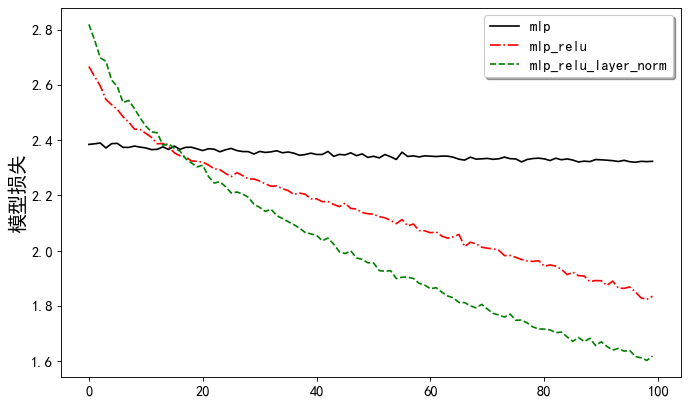

In [15]:
# 展示3种模型的损失下降曲线
fig = plt.figure(figsize=(10, 6), dpi=80)
# 解决中文显示的问题
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams.update({'font.size': 13})
plt.ylabel('模型损失', fontsize=18)
style = ['k', 'r-.', 'g--']
for i, l in enumerate(['mlp', 'mlp_relu', 'mlp_relu_layer_norm']):
    _l = torch.tensor(stats[l]).view(-1, 10).mean(1)
    plt.plot(_l.numpy(), style[i], label=l)
legend = plt.legend(shadow=True)
plt.savefig("mnist_mlp_loss.png", dpi=200)
plt.show()

In [16]:
# 模型会遭遇比较严重的过拟合问题
model2 = nn.Sequential(
    nn.Linear(784, 30, bias=False), nn.LayerNorm(30), nn.ReLU(),
    nn.Linear( 30, 20, bias=False), nn.LayerNorm(20), nn.ReLU(),
    nn.Linear(             20, 10)
)

_ = train_mlp(model2, optim.Adam(model2.parameters(), lr=0.01), train_loader)

epoch  0: train loss 0.1931, val loss 0.2296, test loss 0.2033
          train acc 0.9462, val acc 0.9362, test acc 0.9408
epoch  1: train loss 0.1393, val loss 0.1822, test loss 0.1592
          train acc 0.9612, val acc 0.9458, test acc 0.9494
epoch  2: train loss 0.1172, val loss 0.1658, test loss 0.1314
          train acc 0.9662, val acc 0.9518, test acc 0.9606
epoch  3: train loss 0.1190, val loss 0.1806, test loss 0.1591
          train acc 0.9648, val acc 0.9476, test acc 0.9546
epoch  4: train loss 0.0882, val loss 0.1441, test loss 0.1200
          train acc 0.9736, val acc 0.9584, test acc 0.9646
epoch  5: train loss 0.0726, val loss 0.1341, test loss 0.1097
          train acc 0.9774, val acc 0.9600, test acc 0.9676
epoch  6: train loss 0.0627, val loss 0.1396, test loss 0.1308
          train acc 0.9802, val acc 0.9606, test acc 0.9618
epoch  7: train loss 0.0613, val loss 0.1314, test loss 0.0981
          train acc 0.9828, val acc 0.9618, test acc 0.9714
epoch  8: train 

In [17]:
# 展示模型评估模式和训练模式的差别
m = nn.Dropout(0.5)
x = torch.randn(5)
# 创建之后，模型处于训练模式
print(x, m(x))
# 模型处于评估模式
m.eval()
print(x, m(x))
# 模型处于训练模式
m.train()
print(x, m(x))

tensor([-0.2555,  1.0746, -1.3303, -1.2035,  0.6537]) tensor([-0.0000,  0.0000, -2.6605, -0.0000,  1.3075])
tensor([-0.2555,  1.0746, -1.3303, -1.2035,  0.6537]) tensor([-0.2555,  1.0746, -1.3303, -1.2035,  0.6537])
tensor([-0.2555,  1.0746, -1.3303, -1.2035,  0.6537]) tensor([-0.5110,  0.0000, -0.0000, -0.0000,  0.0000])


In [18]:
# 加入dropout之后会减轻过拟合的问题
model3 = nn.Sequential(
    nn.Linear(784, 30, bias=False), nn.LayerNorm(30), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear( 30, 20, bias=False), nn.LayerNorm(20), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(             20, 10)
)

_ = train_mlp(model3, optim.Adam(model3.parameters(), lr=0.01), train_loader, epochs=50)

epoch  0: train loss 0.2783, val loss 0.2777, test loss 0.2686
          train acc 0.9200, val acc 0.9116, test acc 0.9228
epoch  1: train loss 0.2265, val loss 0.2428, test loss 0.2275
          train acc 0.9358, val acc 0.9282, test acc 0.9384
epoch  2: train loss 0.1734, val loss 0.1956, test loss 0.1783
          train acc 0.9506, val acc 0.9424, test acc 0.9504
epoch  3: train loss 0.1540, val loss 0.2133, test loss 0.1809
          train acc 0.9530, val acc 0.9366, test acc 0.9482
epoch  4: train loss 0.1473, val loss 0.1846, test loss 0.1742
          train acc 0.9574, val acc 0.9488, test acc 0.9516
epoch  5: train loss 0.1444, val loss 0.1792, test loss 0.1660
          train acc 0.9598, val acc 0.9502, test acc 0.9554
epoch  6: train loss 0.1321, val loss 0.1683, test loss 0.1641
          train acc 0.9608, val acc 0.9518, test acc 0.9552
epoch  7: train loss 0.1300, val loss 0.1710, test loss 0.1877
          train acc 0.9644, val acc 0.9518, test acc 0.9474
epoch  8: train 

In [19]:
# 定义l1和l2惩罚项
def l1_loss(model, weight):
    w = torch.cat([p.view(-1) for p in model.parameters()])
    return weight * torch.abs(w).sum()

def l2_loss(model, weight):
    w = torch.cat([p.view(-1) for p in model.parameters()])
    return weight * torch.square(w).sum()

In [20]:
# 使用l2惩罚性
model2 = nn.Sequential(
    nn.Linear(784, 30, bias=False), nn.LayerNorm(30), nn.ReLU(),
    nn.Linear( 30, 20, bias=False), nn.LayerNorm(20), nn.ReLU(),
    nn.Linear(             20, 10)
)

p2 = lambda m: l2_loss(m, 0.001)
_ = train_mlp(model2, optim.Adam(model2.parameters(), lr=0.01), train_loader, penalty=[p2])

epoch  0: train loss 0.2211, val loss 0.2295, test loss 0.2224
          train acc 0.9418, val acc 0.9384, test acc 0.9354
epoch  1: train loss 0.1825, val loss 0.2071, test loss 0.1886
          train acc 0.9484, val acc 0.9442, test acc 0.9470
epoch  2: train loss 0.1412, val loss 0.1655, test loss 0.1559
          train acc 0.9608, val acc 0.9540, test acc 0.9560
epoch  3: train loss 0.1337, val loss 0.1711, test loss 0.1605
          train acc 0.9644, val acc 0.9522, test acc 0.9562
epoch  4: train loss 0.1217, val loss 0.1588, test loss 0.1418
          train acc 0.9630, val acc 0.9526, test acc 0.9594
epoch  5: train loss 0.1156, val loss 0.1741, test loss 0.1526
          train acc 0.9678, val acc 0.9466, test acc 0.9554
epoch  6: train loss 0.1330, val loss 0.1881, test loss 0.1435
          train acc 0.9596, val acc 0.9420, test acc 0.9540
epoch  7: train loss 0.1498, val loss 0.1744, test loss 0.1712
          train acc 0.9566, val acc 0.9484, test acc 0.9522
epoch  8: train 